In [34]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler  

In [35]:
diabetes = pd.read_csv("../data/diabetes_dataset_new_variables.csv")
cols_to_scale = [
    "age",
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "bmi",
    "waist_to_hip_ratio",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "cholesterol_total",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides",
    "glucose_fasting",
    "insulin_level",
    "hba1c",
    "diabetes_risk_score",
    "glucose_postprandial",
    "insulin_resistance",
    "glycemia_spike",
    "obesity_index",
    "pulse_pressure",
    "map",
    "ratio_ldl_hdl",
    "clinical_risk_score"
]

diabetes_minmax = diabetes.copy()
diabetes_standard = diabetes.copy()

missing=diabetes.loc[diabetes.isna().any(axis=1)]
missing

# Does not exist null values in the dataset

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,diagnosed_diabetes,insulin_resistance,glycemia_spike,obesity_index,pulse_pressure,map,ratio_ldl_hdl,clinical_risk_score,age_groups,weight_status


In [36]:
# Normalization (Min-Max) -> Everything between 0 and 1
scaler_minmax = MinMaxScaler()
diabetes_minmax[cols_to_scale] = scaler_minmax.fit_transform(diabetes[cols_to_scale])

# Standardization (StandardScaler) -> Mean 0, Standard Deviation 1
scaler_standard = StandardScaler()
diabetes_standard[cols_to_scale] = scaler_standard.fit_transform(diabetes[cols_to_scale])

In the cells below, we compare the data of one column before standardization with the data after standardization

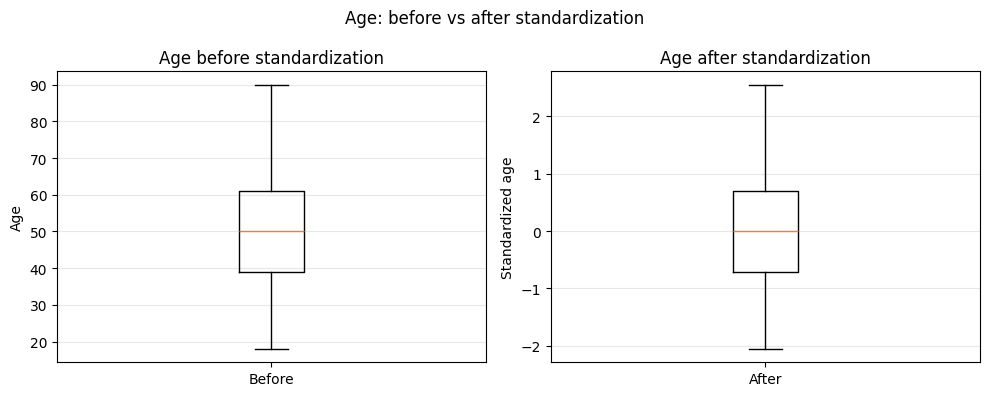

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

axes[0].boxplot([diabetes['age']], tick_labels=['Before'])
axes[0].set_title('Age before standardization')
axes[0].set_ylabel('Age')
axes[0].grid(axis='y', alpha=0.3)

axes[1].boxplot([diabetes_standard['age']], tick_labels=['After'])
axes[1].set_title('Age after standardization')
axes[1].set_ylabel('Standardized age')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Age: before vs after standardization')
plt.tight_layout()
plt.show()

In [38]:
age_before_mean = diabetes['age'].mean()
age_before_std = diabetes['age'].std()

age_after_mean = diabetes_standard['age'].mean()
age_after_std = diabetes_standard['age'].std()

print(f"Age before standardization -> mean: {age_before_mean:.4f}, std: {age_before_std:.4f}")
print(f"Age after standardization -> mean: {age_after_mean:.4f}, std: {age_after_std:.4f}")

Age before standardization -> mean: 50.1204, std: 15.6046
Age after standardization -> mean: 0.0000, std: 1.0000


In the cells below, we compare the data of one column before normalization with the data after normalization 

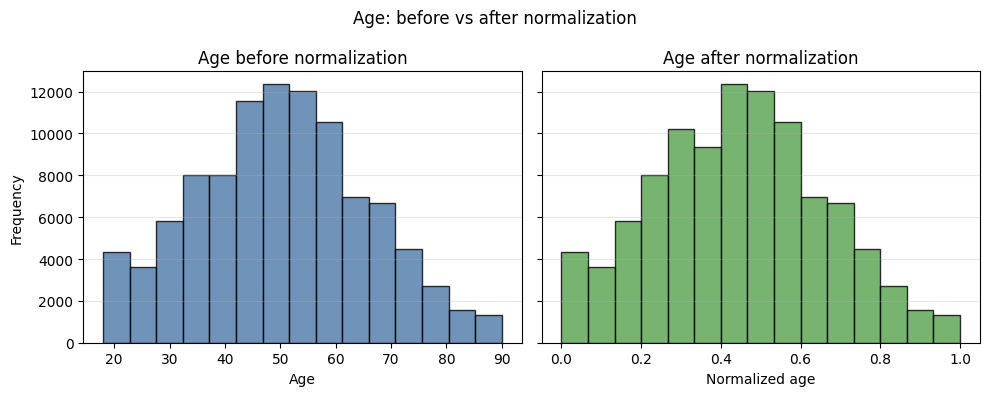

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(diabetes['age'], bins=15, color='#4C78A8', alpha=0.8, edgecolor='black')
axes[0].set_title('Age before normalization')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(diabetes_minmax['age'], bins=15, color='#54A24B', alpha=0.8, edgecolor='black')
axes[1].set_title('Age after normalization')
axes[1].set_xlabel('Normalized age')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Age: before vs after normalization')
plt.tight_layout()
plt.show()

In [40]:
age_before_min = diabetes['age'].min()
age_before_max = diabetes['age'].max()

age_after_min = diabetes_minmax['age'].min()
age_after_max = diabetes_minmax['age'].max()

print(f"Age before normalization -> min: {age_before_min}, max: {age_before_max}")
print(f"Age after normalization -> min: {age_after_min}, max: {age_after_max}")

Age before normalization -> min: 18, max: 90
Age after normalization -> min: 0.0, max: 1.0
